Linear Regression Joblib and Pickle

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [21]:
df = pd.read_csv('driver_behavior.csv')

le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

In [25]:
X = df[[
    'speed_kmph',
    'accel_x',
    'accel_y',
    'brake_pressure',
    'steering_angle',
    'throttle',
    'lane_deviation',
    'phone_usage',
    'headway_distance',
    'reaction_time'
]]

y = df['behavior_label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

y_pred = multiple_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

accuracy = r2 * 100

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("MULTIPLE LINEAR REGRESSION")

print(f"R² Score       : {r2:.4f}")
print(f"Accuracy (%)   : {accuracy:.2f}%")
print(f"RMSE           : {rmse:.4f}")

MULTIPLE LINEAR REGRESSION
R² Score       : 0.9359
Accuracy (%)   : 93.59%
RMSE           : 0.2063


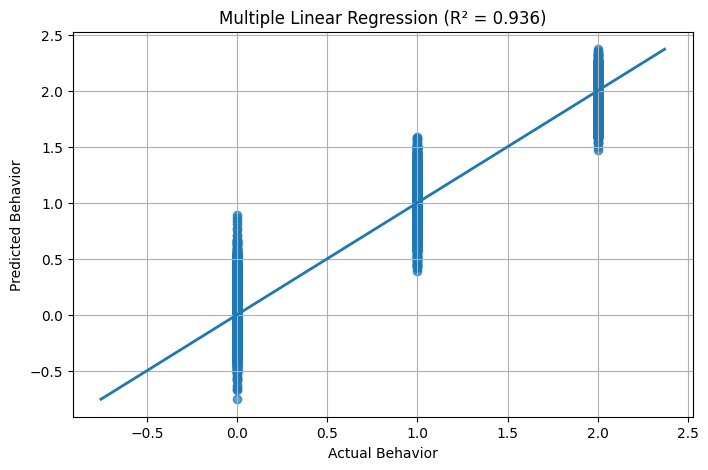

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Actual Behavior")

plt.ylabel("Predicted Behavior")

plt.title(f"Multiple Linear Regression (R² = {r2:.3f})")

plt.grid(True)

plt.show()

In [27]:
with open('multiple_linear_regression_model.pkl', 'wb') as file:
    pickle.dump(multiple_model, file)

print("Multiple Linear Regression model saved successfully as .pkl")

joblib.dump(multiple_model, 'multiple_linear_regression_model.joblib')

print("Multiple Linear Regression model saved successfully as .joblib")

Multiple Linear Regression model saved successfully as .pkl
Multiple Linear Regression model saved successfully as .joblib
